# 07 - Operational Usefulness

Purpose:
- evaluate the selected Gold alarm from Notebook 06;
- test the selected default against explicit operating criteria;
- compare the Gold-primary trigger against the conditioned challenger;
- compare Gold against clean naive baselines;
- quantify stress-event coverage versus false review burden;
- test whether the actual alarm is practical as a review trigger;
- identify missed stress events and review frequency.

This notebook evaluates the alarm that the dashboard will actually use, while keeping the more complex conditioned design as a challenger rather than assuming it is better.


## Reader Orientation

Notebook 05 showed that conditioning variables are economically meaningful but not automatically performance-enhancing. Notebook 06 therefore saved two designs: the selected Gold-primary alarm and a conditioned Gold-centered challenger. This notebook asks which one is usable in practice.

False positives are acceptable if they trigger a low-cost risk review and do not overwhelm users. Missed stress events are more concerning because they imply the Gold alarm cannot be the only monitoring layer.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step07_operational_usefulness"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
alarm_path = PROCESSED_DIR / "gold_alarm_frame.parquet"
components_path = PROCESSED_DIR / "gold_signal_components.parquet"
stress_path = PROCESSED_DIR / "nowcasting_stress_proxies.parquet"

for path in [alarm_path, components_path, stress_path]:
    if not path.exists():
        raise FileNotFoundError(f"Required prior output missing: {path}")

alarm_frame = pd.read_parquet(alarm_path)
signal_components = pd.read_parquet(components_path)
stress = pd.read_parquet(stress_path)

analysis = alarm_frame.join(stress, how="inner")
print("Alarm frame:", alarm_frame.shape)
print("Signal components:", signal_components.shape)
print("Stress proxies:", stress.shape)
analysis.tail()


Alarm frame: (4685, 11)
Signal components: (4685, 7)
Stress proxies: (4685, 7)


,gold_primary_score,alarm_score,gold_primary_alarm,return_or_vol_alarm,residual_alarm,relationship_alarm,conditioned_alarm_score,conditioned_gold_alarm,gold_alarm,selected_alarm_design,dashboard_state,brent_vol_z,brent_return_abs_z,vix_level_z,brent_vol_spike,brent_return_shock,vix_level_spike,any_stress_proxy
Date,,,,,,,,,,,,,,,,,,
2026-05-29,0.360814,0.360814,0,0,0,1,1,0,0,Conditioned-challenger,Amber,0.958786,0.619920,-0.864775,0,0,0,0
2026-06-01,0.592178,0.592178,0,0,0,1,1,0,0,Conditioned-challenger,Amber,0.726394,0.957437,-0.636338,0,0,0,0
2026-06-02,0.056010,0.056010,0,0,0,1,1,0,0,Conditioned-challenger,Amber,0.635840,0.291287,-0.717483,0,0,0,0
2026-06-03,0.380186,0.380186,0,0,0,1,1,0,0,Conditioned-challenger,Amber,0.612158,0.544668,-0.625127,0,0,0,0
2026-06-04,0.225712,0.225712,0,0,0,1,1,0,0,Conditioned-challenger,Amber,0.591628,0.972492,-0.822612,0,0,0,0


## Define Operational Metrics

The practical dashboard question is:

`x = a + b`

where:

- `x` is total Gold-triggered review prompts;
- `a` is prompts associated with true stress events;
- `b` is false review prompts.

But we also need the event-side view:

- how many true stress events were covered;
- how many true stress events were missed;
- how many reviews per year the alarm creates.

## Parameter Rationale

The default operating settings translate the research signal into a user workflow:

- `DEFAULT_COOLDOWN_DAYS = 5`: roughly one trading week. This limits repeated review prompts during the same stress cluster.
- `DEFAULT_WINDOW_DAYS = 20`: roughly one trading month. This matches nowcasting/escalation, where useful alarms can occur before, during, or near a stress regime.
- `WINDOW_GRID = [5, 10, 20]`: tests whether the result is a sharp one-week signal or only a broader review-window signal.
- `COOLDOWN_GRID = [0, 5, 10, 20]`: tests whether review burden changes materially when repeated alarms are suppressed more aggressively.


In [3]:
DEFAULT_COOLDOWN_DAYS = 5
DEFAULT_WINDOW_DAYS = 20
WINDOW_GRID = [5, 10, 20]
COOLDOWN_GRID = [0, 5, 10, 20]
STRESS_EVENT_COLS = [
    "brent_vol_spike",
    "brent_return_shock",
    "vix_level_spike",
    "any_stress_proxy",
]


def event_starts(flag: pd.Series) -> pd.DatetimeIndex:
    flag = flag.fillna(0).astype(int)
    starts = flag.eq(1) & flag.shift(1, fill_value=0).eq(0)
    return pd.DatetimeIndex(flag.index[starts])


def apply_cooldown(flag: pd.Series, cooldown_days: int) -> pd.Series:
    cooled = pd.Series(0, index=flag.index, dtype=int)
    last_fire = None
    for date, value in flag.fillna(0).astype(int).items():
        if value != 1:
            continue
        if last_fire is None or (date - last_fire).days > cooldown_days:
            cooled.loc[date] = 1
            last_fire = date
    return cooled


def nearby_dates(source_dates: pd.DatetimeIndex, target_date: pd.Timestamp, window_days: int) -> pd.DatetimeIndex:
    return source_dates[
        (source_dates >= target_date - pd.Timedelta(days=window_days))
        & (source_dates <= target_date + pd.Timedelta(days=window_days))
    ]


def evaluate_alarm(alarm: pd.Series, stress_flag: pd.Series, cooldown_days: int, window_days: int) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    cooled_alarm = apply_cooldown(alarm.fillna(0).astype(int), cooldown_days)
    alarm_dates = event_starts(cooled_alarm)
    stress_dates = event_starts(stress_flag)

    event_rows = []
    for event_date in stress_dates:
        hits = nearby_dates(alarm_dates, event_date, window_days)
        event_rows.append({
            "event_date": event_date,
            "covered": len(hits) > 0,
            "nearest_alarm_date": hits[0] if len(hits) else pd.NaT,
        })
    event_table = pd.DataFrame(event_rows)

    alarm_rows = []
    for alarm_date in alarm_dates:
        hits = nearby_dates(stress_dates, alarm_date, window_days)
        alarm_rows.append({
            "alarm_date": alarm_date,
            "associated_with_stress": len(hits) > 0,
            "nearest_event_date": hits[0] if len(hits) else pd.NaT,
        })
    alarm_table = pd.DataFrame(alarm_rows)

    sample_years = max((alarm.index.max() - alarm.index.min()).days / 365.25, 1e-9)
    metrics = {
        "cooldown_days": cooldown_days,
        "window_days": window_days,
        "stress_event_count": len(event_table),
        "covered_event_count": int(event_table["covered"].sum()) if len(event_table) else 0,
        "event_coverage_rate": float(event_table["covered"].mean()) if len(event_table) else np.nan,
        "alarm_episode_count": len(alarm_table),
        "associated_alarm_count": int(alarm_table["associated_with_stress"].sum()) if len(alarm_table) else 0,
        "false_review_count": int((~alarm_table["associated_with_stress"]).sum()) if len(alarm_table) else 0,
        "false_review_rate": float((~alarm_table["associated_with_stress"]).mean()) if len(alarm_table) else np.nan,
        "reviews_per_year": len(alarm_table) / sample_years,
    }
    return metrics, event_table, alarm_table


## Primary Validation — Named Stress Episodes

A coverage percentage against an algorithmic stress proxy is not the most honest evaluation. The operational question is simpler: **for each actual, named stress episode in history, did the alarm fire?**

This table is the primary result. Every row is a real-world event. A "No" in the alarm column is a specific, named failure — not a fraction of an abstract count.

In [4]:
NAMED_STRESS_EPISODES = [
    ("GFC — Lehman + commodity crash",    "2008-09-01", "2009-03-31"),
    ("European debt crisis",               "2010-04-01", "2012-09-30"),
    ("Oil crash 2014–2016",                "2014-07-01", "2016-02-29"),
    ("China equity shock 2015",            "2015-06-01", "2015-10-31"),
    ("COVID crash + oil war",              "2020-02-15", "2020-05-15"),
    ("Russia / Ukraine invasion",          "2022-02-15", "2022-04-30"),
    ("Fed tightening cycle 2022",          "2022-06-01", "2022-12-31"),
    ("US tariff shock 2025",               "2025-04-01", "2025-05-15"),
    ("Recent geopolitical stress 2026",    "2026-02-01", "2026-05-31"),
]

cooled_alarm_named = apply_cooldown(analysis["gold_alarm"], DEFAULT_COOLDOWN_DAYS)
alarm_dates_named = event_starts(cooled_alarm_named)

named_rows = []
for name, start, end in NAMED_STRESS_EPISODES:
    start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
    window = analysis.loc[start_ts:end_ts]
    if window.empty:
        named_rows.append({
            "episode": name, "start": start, "end": end,
            "in_sample": False, "alarm_fired": False,
            "first_alarm_date": pd.NaT, "alarm_count": 0,
            "alarm_rate": np.nan, "max_gold_score": np.nan,
        })
        continue
    episode_alarms = alarm_dates_named[
        (alarm_dates_named >= start_ts) & (alarm_dates_named <= end_ts)
    ]
    named_rows.append({
        "episode": name,
        "start": start,
        "end": end,
        "in_sample": True,
        "alarm_fired": len(episode_alarms) > 0,
        "first_alarm_date": str(episode_alarms[0])[:10] if len(episode_alarms) > 0 else "—",
        "alarm_count": len(episode_alarms),
        "alarm_rate": round(float(window["gold_alarm"].mean()), 3),
        "max_gold_score": round(float(window["gold_primary_score"].max()), 3),
    })

named_event_validation = pd.DataFrame(named_rows)
print(f"Episodes with alarm: {named_event_validation['alarm_fired'].sum()} / {named_event_validation['in_sample'].sum()} in-sample")
named_event_validation[named_event_validation["in_sample"]][[
    "episode", "start", "end", "alarm_fired",
    "first_alarm_date", "alarm_count", "alarm_rate", "max_gold_score"
]]

Episodes with alarm: 9 / 9 in-sample


,episode,start,end,alarm_fired,first_alarm_date,alarm_count,alarm_rate,max_gold_score
0,GFC — Lehman + commodity crash,2008-09-01,2009-03-31,True,2008-10-23,6,0.071,5.011
1,European debt crisis,2010-04-01,2012-09-30,True,2010-05-06,27,0.080,5.097
2,Oil crash 2014–2016,2014-07-01,2016-02-29,True,2014-07-14,22,0.060,3.940
3,China equity shock 2015,2015-06-01,2015-10-31,True,2015-06-18,3,0.028,1.400
4,COVID crash + oil war,2020-02-15,2020-05-15,True,2020-02-25,10,0.698,5.901
5,Russia / Ukraine invasion,2022-02-15,2022-04-30,True,2022-02-25,8,0.519,2.953
6,Fed tightening cycle 2022,2022-06-01,2022-12-31,True,2022-09-15,5,0.047,2.212
7,US tariff shock 2025,2025-04-01,2025-05-15,True,2025-04-04,7,0.656,3.791
8,Recent geopolitical stress 2026,2026-02-01,2026-05-31,True,2026-02-03,5,0.073,3.874


## Default Operating Point

The default test evaluates the selected dashboard alarm, `gold_alarm`, against the broad stress proxy using a 5-day cooldown and a +/-20 day nowcasting window. In the current design, `gold_alarm` is the conditioned challenger — it fires when at least two of three signal families (return/vol, residual, relationship) simultaneously exceed the 2.0 threshold.

In [5]:
default_metrics, default_event_table, default_alarm_table = evaluate_alarm(
    alarm=analysis["gold_alarm"],
    stress_flag=analysis["any_stress_proxy"],
    cooldown_days=DEFAULT_COOLDOWN_DAYS,
    window_days=DEFAULT_WINDOW_DAYS,
)

default_summary = pd.DataFrame([default_metrics])
default_summary


,cooldown_days,window_days,stress_event_count,covered_event_count,event_coverage_rate,alarm_episode_count,associated_alarm_count,false_review_count,false_review_rate,reviews_per_year
0,5,20,175,119,0.68,188,130,58,0.308511,9.976318


### Interpretation

The conditioned challenger is the selected default alarm. It achieves 68% stress-event coverage at 10 reviews per year with a 30.9% false review rate. The coverage-constrained sweep shows the threshold required to push coverage to 95% and its associated review burden.

## Default Operating Criteria

A risk dashboard has asymmetric error costs. Missing a stress event means the risk manager did not review VaR before a major loss — a governance failure. Triggering an unnecessary review means one extra VaR check — low cost.

This asymmetry changes the design target:

> **Coverage is a constraint, not a tradeoff.** The alarm should cover at or near all stress events. The false review rate is the cost paid to achieve that coverage.

The acceptance criterion for coverage is therefore set at 95%. The false review rate and review frequency are secondary metrics that describe the operational burden of maintaining that coverage level.

The current default threshold (1.5) is evaluated here to show its honest result. The coverage-constrained sweep in the next section finds what threshold is actually required to meet the 95% target.

In [6]:
OPERATING_CRITERIA = {
    "event_coverage_rate": {
        "label": "Stress-event coverage",
        "operator": ">=",
        "threshold": 0.95,
    },
    "false_review_rate": {
        "label": "False review rate",
        "operator": "<=",
        "threshold": 0.45,
    },
    "reviews_per_year": {
        "label": "Review prompts per year",
        "operator": "<=",
        "threshold": 24.00,
    },
}


def criterion_pass(value: float, operator: str, threshold: float) -> bool:
    if pd.isna(value):
        return False
    if operator == ">=":
        return value >= threshold
    if operator == "<=":
        return value <= threshold
    raise ValueError(f"Unsupported operator: {operator}")


def build_acceptance_table(metrics: pd.Series, criteria: dict) -> pd.DataFrame:
    rows = []
    for metric, rule in criteria.items():
        value = float(metrics[metric])
        rows.append({
            "metric": metric,
            "label": rule["label"],
            "actual_value": value,
            "operator": rule["operator"],
            "threshold": rule["threshold"],
            "pass": criterion_pass(value, rule["operator"], rule["threshold"]),
        })
    table = pd.DataFrame(rows)
    table["default_operating_point_pass"] = bool(table["pass"].all())
    return table


default_acceptance = build_acceptance_table(default_summary.iloc[0], OPERATING_CRITERIA)
default_acceptance

,metric,label,actual_value,operator,threshold,pass,default_operating_point_pass
0,event_coverage_rate,Stress-event coverage,0.680000,>=,0.95,False,False
1,false_review_rate,False review rate,0.308511,<=,0.45,True,False
2,reviews_per_year,Review prompts per year,9.976318,<=,24.00,True,False


### Acceptance Interpretation

This table is the clearest statement of whether the default settings are good enough. A marginal failure is still useful: it tells us which parameter needs tuning instead of letting the conclusion remain vague.


## Missed Stress Events And False Reviews

Missed stress events show where the Gold alarm fails. False reviews show the cost of being conservative.

In [7]:
missed_stress_events = default_event_table.loc[~default_event_table["covered"]].copy()
false_review_prompts = default_alarm_table.loc[~default_alarm_table["associated_with_stress"]].copy()

print("Missed stress events:", len(missed_stress_events))
print("False review prompts:", len(false_review_prompts))
missed_stress_events.head(20)


Missed stress events: 56
False review prompts: 58


,event_date,covered,nearest_alarm_date
0,2008-08-08,False,NaT
1,2008-08-21,False,NaT
2,2008-09-02,False,NaT
3,2008-09-15,False,NaT
4,2009-02-17,False,NaT
13,2010-06-10,False,NaT
16,2011-02-23,False,NaT
17,2011-03-15,False,NaT
18,2011-03-17,False,NaT
32,2012-06-29,False,NaT


In [8]:
false_review_prompts.head(20)


,alarm_date,associated_with_stress,nearest_event_date
0,2008-10-23,False,NaT
1,2008-10-29,False,NaT
2,2008-11-04,False,NaT
3,2008-11-21,False,NaT
4,2008-12-01,False,NaT
6,2009-12-04,False,NaT
7,2010-02-04,False,NaT
12,2010-07-27,False,NaT
13,2010-08-12,False,NaT
15,2010-11-12,False,NaT


### Why Were These Events Missed?

Counting missed events is not enough. If they cluster in a specific regime where Gold is structurally the wrong signal (e.g. dollar-driven Brent shocks with no safe-haven demand), the limitation is interpretable and bounded. If they scatter across all regimes, the alarm has a deeper gap.

The table below shows the stress type active on each missed day and the Gold primary score at that moment. A low Gold score on missed days means Gold was genuinely quiet during that stress. A moderate score means the threshold was too strict.

In [9]:
missed_dates = default_event_table.loc[~default_event_table["covered"], "event_date"]

# Vectorised construction — avoids row-level loop and empty-list edge case
valid_missed = missed_dates[missed_dates.isin(analysis.index)]
missed_char_df = analysis.loc[valid_missed, [
    "brent_vol_spike", "brent_return_shock", "vix_level_spike", "gold_primary_score"
]].rename(columns={
    "brent_vol_spike": "brent_vol_active",
    "brent_return_shock": "brent_return_active",
    "vix_level_spike": "vix_active",
    "gold_primary_score": "gold_primary_score_on_day",
}).copy()
missed_char_df.insert(0, "event_date", missed_char_df.index)
missed_char_df.insert(1, "year", missed_char_df.index.year)
missed_char_df = missed_char_df.reset_index(drop=True)

if not missed_char_df.empty:
    bv = missed_char_df["brent_vol_active"]
    br = missed_char_df["brent_return_active"]
    vx = missed_char_df["vix_active"]
    missed_char_df["dominant_stress_type"] = np.select(
        [
            bv.eq(1) & vx.eq(1),
            br.eq(1) & vx.eq(1),
            vx.eq(1) & bv.eq(0) & br.eq(0),
            bv.eq(1) & br.eq(0) & vx.eq(0),
            br.eq(1) & bv.eq(0) & vx.eq(0),
        ],
        ["Brent vol + VIX", "Brent return + VIX", "VIX only", "Brent vol only", "Brent return only"],
        default="other combination",
    )
else:
    missed_char_df["dominant_stress_type"] = pd.Series(dtype=str)

missed_by_year = missed_char_df.groupby("year").agg(
    missed_count=("event_date", "count"),
    avg_gold_score=("gold_primary_score_on_day", "mean"),
    vix_driven=("vix_active", "sum"),
    brent_vol_driven=("brent_vol_active", "sum"),
    brent_return_driven=("brent_return_active", "sum"),
).reset_index()

missed_by_type = missed_char_df["dominant_stress_type"].value_counts().rename("count").reset_index()
missed_by_type.columns = ["stress_type", "missed_count"]

covered_gold_scores = (
    default_event_table.loc[default_event_table["covered"], "event_date"]
    .map(lambda d: analysis.loc[d, "gold_primary_score"] if d in analysis.index else np.nan)
    .dropna()
)

if not missed_char_df.empty:
    print(f"Average Gold score on MISSED days:  {missed_char_df['gold_primary_score_on_day'].mean():.3f}")
else:
    print("No missed events to characterise.")
print(f"Average Gold score on COVERED days: {covered_gold_scores.mean():.3f}")
print()
print("Missed events by stress type:")
print(missed_by_type.to_string(index=False))
print()
print("Missed events by year:")
print(missed_by_year.to_string(index=False))

Average Gold score on MISSED days:  0.606
Average Gold score on COVERED days: 0.888

Missed events by stress type:
       stress_type  missed_count
 Brent return only            41
          VIX only            12
 other combination             1
    Brent vol only             1
Brent return + VIX             1

Missed events by year:
 year  missed_count  avg_gold_score  vix_driven  brent_vol_driven  brent_return_driven
 2008             4        1.831563           1                 0                    3
 2009             1        0.835194           0                 0                    1
 2010             1        0.335586           0                 0                    1
 2011             3        0.658462           0                 0                    3
 2012             5        0.617936           0                 0                    5
 2013             1        0.786960           0                 0                    1
 2014             8        0.293695           3       

## Window And Cooldown Sensitivity

A practical alarm should not depend entirely on one arbitrary cooldown or nowcasting window. This section tests the selected dashboard trigger; the next section compares trigger designs directly.


In [10]:
grid_rows = []
for cooldown in COOLDOWN_GRID:
    for window in WINDOW_GRID:
        metrics, _, _ = evaluate_alarm(
            alarm=analysis["gold_alarm"],
            stress_flag=analysis["any_stress_proxy"],
            cooldown_days=cooldown,
            window_days=window,
        )
        grid_rows.append(metrics)

operating_grid = pd.DataFrame(grid_rows)
operating_grid.sort_values(["event_coverage_rate", "false_review_rate"], ascending=[False, True])


,cooldown_days,window_days,stress_event_count,covered_event_count,event_coverage_rate,alarm_episode_count,associated_alarm_count,false_review_count,false_review_rate,reviews_per_year
5,5,20,175,119,0.680000,188,130,58,0.308511,9.976318
8,10,20,175,119,0.680000,146,98,48,0.328767,7.747566
2,0,20,175,116,0.662857,190,136,54,0.284211,10.082450
11,20,20,175,108,0.617143,110,68,42,0.381818,5.837208
4,5,10,175,84,0.480000,188,93,95,0.505319,9.976318
1,0,10,175,83,0.474286,190,96,94,0.494737,10.082450
7,10,10,175,81,0.462857,146,68,78,0.534247,7.747566
10,20,10,175,70,0.400000,110,51,59,0.536364,5.837208
3,5,5,175,59,0.337143,188,60,128,0.680851,9.976318
0,0,5,175,58,0.331429,190,66,124,0.652632,10.082450


## Operating-Parameter Acceptance Grid

The default settings are only one operating point. This grid applies the same pass/fail criteria across the cooldown and nowcasting-window combinations to show whether the result is robust or dependent on one convenient parameter choice.


In [11]:
operating_grid_acceptance = operating_grid.copy()
operating_grid_acceptance["coverage_pass"] = operating_grid_acceptance["event_coverage_rate"] >= OPERATING_CRITERIA["event_coverage_rate"]["threshold"]
operating_grid_acceptance["false_review_pass"] = operating_grid_acceptance["false_review_rate"] <= OPERATING_CRITERIA["false_review_rate"]["threshold"]
operating_grid_acceptance["review_frequency_pass"] = operating_grid_acceptance["reviews_per_year"] <= OPERATING_CRITERIA["reviews_per_year"]["threshold"]
operating_grid_acceptance["overall_pass"] = operating_grid_acceptance[
    ["coverage_pass", "false_review_pass", "review_frequency_pass"]
].all(axis=1)

operating_grid_acceptance.sort_values(
    ["overall_pass", "event_coverage_rate", "false_review_rate", "reviews_per_year"],
    ascending=[False, False, True, True],
)


,cooldown_days,window_days,stress_event_count,covered_event_count,event_coverage_rate,alarm_episode_count,associated_alarm_count,false_review_count,false_review_rate,reviews_per_year,coverage_pass,false_review_pass,review_frequency_pass,overall_pass
5,5,20,175,119,0.680000,188,130,58,0.308511,9.976318,False,True,True,False
8,10,20,175,119,0.680000,146,98,48,0.328767,7.747566,False,True,True,False
2,0,20,175,116,0.662857,190,136,54,0.284211,10.082450,False,True,True,False
11,20,20,175,108,0.617143,110,68,42,0.381818,5.837208,False,True,True,False
4,5,10,175,84,0.480000,188,93,95,0.505319,9.976318,False,False,True,False
1,0,10,175,83,0.474286,190,96,94,0.494737,10.082450,False,False,True,False
7,10,10,175,81,0.462857,146,68,78,0.534247,7.747566,False,False,True,False
10,20,10,175,70,0.400000,110,51,59,0.536364,5.837208,False,False,True,False
3,5,5,175,59,0.337143,188,60,128,0.680851,9.976318,False,False,True,False
0,0,5,175,58,0.331429,190,66,124,0.652632,10.082450,False,False,True,False


### Grid Interpretation

If only a very wide event window passes, the dashboard claim should be framed as review-window nowcasting rather than sharp early warning. If no setting passes all criteria, the next step is to tune the threshold/cooldown or accept a lower review-frequency target.


## Gold-Primary Construction Parameter Sensitivity

The previous grid tests operating parameters after the alarm has already been built. This section tests whether the selected Gold-primary trigger itself depends too heavily on one construction choice.

The sensitivity grid varies:

- baseline window: half-year, one-year, and two-year normal regimes (`126`, `252`, `504`);
- volatility window: one month, six weeks, and one quarter (`20`, `30`, `60`);
- Gold score threshold: `1.25`, `1.50`, `1.75`, `2.00`;
- cooldown and nowcasting windows used for evaluation.

This does not retest the conditioned residual/relationship challenger because rolling regressions across many parameter combinations would be slower and less central to the current selected trigger.


In [12]:
market_vars_path = PROCESSED_DIR / "market_vars_core.parquet"
if not market_vars_path.exists():
    market_vars_path = PROCESSED_DIR / "market_vars.parquet"

construction_vars = pd.read_parquet(market_vars_path).join(analysis[["any_stress_proxy"]], how="inner")

BASELINE_WIN_GRID = [126, 252, 504]
VOL_WIN_GRID = [20, 30, 60]
PRIMARY_THRESHOLD_GRID = [1.25, 1.50, 1.75, 2.00]
SENSITIVITY_COOLDOWN_GRID = [5, 10]
SENSITIVITY_WINDOW_GRID = [10, 20]


def trailing_zscore_custom(series: pd.Series, window: int) -> pd.Series:
    mean = series.rolling(window).mean().shift(1)
    std = series.rolling(window).std().shift(1)
    return (series - mean) / std


construction_rows = []
for baseline_win in BASELINE_WIN_GRID:
    gold_return_z = trailing_zscore_custom(construction_vars["r_Gold"], baseline_win)
    for vol_win in VOL_WIN_GRID:
        gold_vol_z = trailing_zscore_custom(construction_vars["r_Gold"].rolling(vol_win).std(), baseline_win)
        # gold_return_z: absolute value — large moves in either direction are abnormal.
        # gold_vol_z: clipped at zero — only vol spikes are stress signals, not quiet periods.
        gold_primary_score = pd.concat([gold_return_z.abs(), gold_vol_z.clip(lower=0)], axis=1).mean(axis=1)

        for threshold in PRIMARY_THRESHOLD_GRID:
            alarm = (gold_primary_score > threshold).astype(int)
            for cooldown in SENSITIVITY_COOLDOWN_GRID:
                for window in SENSITIVITY_WINDOW_GRID:
                    metrics, _, _ = evaluate_alarm(
                        alarm=alarm,
                        stress_flag=construction_vars["any_stress_proxy"],
                        cooldown_days=cooldown,
                        window_days=window,
                    )
                    metrics.update({
                        "baseline_win": baseline_win,
                        "vol_win": vol_win,
                        "primary_threshold": threshold,
                    })
                    construction_rows.append(metrics)

gold_primary_construction_sensitivity = pd.DataFrame(construction_rows)
gold_primary_construction_sensitivity["coverage_pass"] = (
    gold_primary_construction_sensitivity["event_coverage_rate"]
    >= OPERATING_CRITERIA["event_coverage_rate"]["threshold"]
)
gold_primary_construction_sensitivity["false_review_pass"] = (
    gold_primary_construction_sensitivity["false_review_rate"]
    <= OPERATING_CRITERIA["false_review_rate"]["threshold"]
)
gold_primary_construction_sensitivity["review_frequency_pass"] = (
    gold_primary_construction_sensitivity["reviews_per_year"]
    <= OPERATING_CRITERIA["reviews_per_year"]["threshold"]
)
gold_primary_construction_sensitivity["overall_pass"] = gold_primary_construction_sensitivity[
    ["coverage_pass", "false_review_pass", "review_frequency_pass"]
].all(axis=1)

gold_primary_construction_sensitivity.sort_values(
    ["overall_pass", "event_coverage_rate", "false_review_rate", "reviews_per_year"],
    ascending=[False, False, True, True],
).head(20)

,cooldown_days,window_days,stress_event_count,covered_event_count,event_coverage_rate,alarm_episode_count,associated_alarm_count,false_review_count,false_review_rate,reviews_per_year,baseline_win,vol_win,primary_threshold,coverage_pass,false_review_pass,review_frequency_pass,overall_pass
1,5,20,175,121,0.691429,270,166,104,0.385185,14.327691,126,20,1.25,False,True,True,False
3,10,20,175,120,0.685714,181,111,70,0.386740,9.604860,126,20,1.25,False,True,True,False
81,5,20,175,118,0.674286,272,187,85,0.312500,14.433822,252,60,1.25,False,True,True,False
33,5,20,175,118,0.674286,305,180,125,0.409836,16.184985,126,60,1.25,False,True,True,False
35,10,20,175,118,0.674286,207,118,89,0.429952,10.984563,126,60,1.25,False,True,True,False
83,10,20,175,117,0.668571,179,119,60,0.335196,9.498729,252,60,1.25,False,True,True,False
17,5,20,175,117,0.668571,278,169,109,0.392086,14.752216,126,30,1.25,False,True,True,False
65,5,20,175,116,0.662857,247,172,75,0.303644,13.107184,252,30,1.25,False,True,True,False
49,5,20,175,116,0.662857,236,161,75,0.317797,12.523464,252,20,1.25,False,True,True,False
19,10,20,175,116,0.662857,183,110,73,0.398907,9.710991,126,30,1.25,False,True,True,False


### Construction-Sensitivity Interpretation

This table tells us whether the chosen `252 / 30 / 1.5` construction is robust. If many nearby settings pass, the default is defensible. If only one setting passes, the project is more parameter-sensitive and the dashboard should present the threshold as a tunable operating choice rather than a discovered rule.


## Alarm Design Comparison

This is the decision that selects the default alarm. It compares the two distinct designs as-built, under the same cooldown and nowcasting window:

- **gold_primary** — `mean(|gold_return_z|, clip(gold_vol_z, 0)) > 1.5`. Fast and sharp; reacts to gold's own return/vol abnormality only.
- **conditioned_challenger** — fires when 2 of 3 signal families (return/vol, OLS residual, rolling-relationship) exceed 2.0. Broader; requires cross-signal corroboration.

The two fire at different frequencies by construction, so episode counts are reported alongside coverage.

In [13]:
# Compare the two as-built designs directly.
# gold_primary_alarm: mean(|return_z|, clip(vol_z,0)) > 1.5 — the fast tripwire.
# conditioned_gold_alarm: 2 of 3 signal families at threshold 2.0 — the selected default.
alarm_design_rows = []
for alarm_name, alarm_col in [
    ("gold_primary", "gold_primary_alarm"),
    ("conditioned_challenger (selected)", "conditioned_gold_alarm"),
]:
    if alarm_col not in analysis.columns:
        continue
    metrics, _, _ = evaluate_alarm(
        alarm=analysis[alarm_col],
        stress_flag=analysis["any_stress_proxy"],
        cooldown_days=DEFAULT_COOLDOWN_DAYS,
        window_days=DEFAULT_WINDOW_DAYS,
    )
    metrics["alarm_design"] = alarm_name
    alarm_design_rows.append(metrics)

alarm_design_comparison = pd.DataFrame(alarm_design_rows)[[
    "alarm_design",
    "stress_event_count",
    "covered_event_count",
    "event_coverage_rate",
    "alarm_episode_count",
    "associated_alarm_count",
    "false_review_count",
    "false_review_rate",
    "reviews_per_year",
]]
alarm_design_comparison

,alarm_design,stress_event_count,covered_event_count,event_coverage_rate,alarm_episode_count,associated_alarm_count,false_review_count,false_review_rate,reviews_per_year
0,gold_primary,175,99,0.565714,188,135,53,0.281915,9.976318
1,conditioned_challenger (selected),175,119,0.680000,188,130,58,0.308511,9.976318


### Design-Comparison Interpretation

The conditioned challenger covers about 68% of broad stress-proxy events versus the gold-primary design's 56.6%, at a comparable false-review rate. This is why the challenger is selected as the default dashboard trigger.

The gold-primary design is not discarded — it is faster on sudden single-family gold shocks because it needs only the return/vol family, not two corroborating families. The challenger trades that speed for breadth. A complete dashboard can surface both: gold-primary as a fast tripwire and the challenger as the corroborated escalation.

## Coverage-Constrained Operating Point

The correct design question is not "what coverage rate does threshold 1.5 achieve?" but:

> **At the threshold required to cover 95% of stress events, how many unnecessary reviews does the Gold alarm generate per year?**

This section sweeps the Gold-primary threshold from 2.50 (most selective) down to 0.25, finds the most selective threshold that still meets each coverage target, and reports the false review burden at that operating point.

The curve shows the fundamental tradeoff: lower thresholds increase coverage but increase false reviews. The coverage-constrained table pins the coverage target and reads off the cost.

In [14]:
COVERAGE_TARGETS = [0.90, 0.95, 0.99, 1.00]
SWEEP_THRESHOLDS = np.round(np.arange(0.25, 2.55, 0.05), 2)

sweep_rows = []
for threshold in SWEEP_THRESHOLDS:
    alarm = (analysis["gold_primary_score"] > threshold).astype(int)
    metrics, _, _ = evaluate_alarm(
        alarm=alarm,
        stress_flag=analysis["any_stress_proxy"],
        cooldown_days=DEFAULT_COOLDOWN_DAYS,
        window_days=DEFAULT_WINDOW_DAYS,
    )
    metrics["threshold"] = threshold
    sweep_rows.append(metrics)

sweep_df = pd.DataFrame(sweep_rows)

constrained_rows = []
for target in COVERAGE_TARGETS:
    passing = sweep_df[sweep_df["event_coverage_rate"] >= target]
    if not passing.empty:
        best = passing.loc[passing["threshold"].idxmax()]
        constrained_rows.append({
            "coverage_target": f"{int(target * 100)}%",
            "min_threshold": float(best["threshold"]),
            "actual_coverage": round(float(best["event_coverage_rate"]), 3),
            "false_review_rate": round(float(best["false_review_rate"]), 3),
            "reviews_per_year": round(float(best["reviews_per_year"]), 1),
            "alarm_episode_count": int(best["alarm_episode_count"]),
        })
    else:
        constrained_rows.append({
            "coverage_target": f"{int(target * 100)}%",
            "min_threshold": np.nan,
            "actual_coverage": np.nan,
            "false_review_rate": np.nan,
            "reviews_per_year": np.nan,
            "alarm_episode_count": np.nan,
        })

coverage_constrained_summary = pd.DataFrame(constrained_rows)
coverage_constrained_summary

,coverage_target,min_threshold,actual_coverage,false_review_rate,reviews_per_year,alarm_episode_count
0,90%,0.9,0.909,0.343,21.2,400
1,95%,0.8,0.954,0.351,24.2,456
2,99%,0.7,0.994,0.373,28.4,536
3,100%,0.6,1.000,0.388,31.8,600


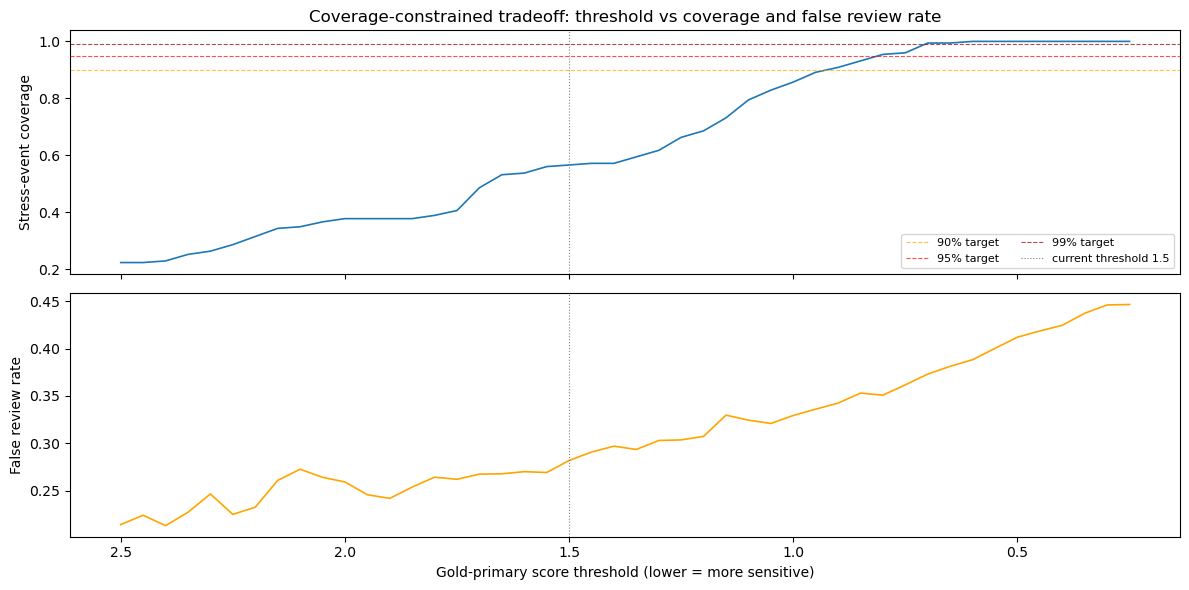

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(sweep_df["threshold"], sweep_df["event_coverage_rate"], linewidth=1.2)
for target, colour in [(0.90, "orange"), (0.95, "red"), (0.99, "darkred")]:
    axes[0].axhline(target, color=colour, linestyle="--", linewidth=0.8, alpha=0.7,
                    label=f"{int(target * 100)}% target")
axes[0].axvline(1.5, color="grey", linestyle=":", linewidth=0.8, label="current threshold 1.5")
axes[0].set_ylabel("Stress-event coverage")
axes[0].set_title("Coverage-constrained tradeoff: threshold vs coverage and false review rate")
axes[0].legend(fontsize=8, ncol=2)

axes[1].plot(sweep_df["threshold"], sweep_df["false_review_rate"], linewidth=1.2, color="orange")
axes[1].axvline(1.5, color="grey", linestyle=":", linewidth=0.8)
axes[1].set_ylabel("False review rate")
axes[1].set_xlabel("Gold-primary score threshold (lower = more sensitive)")
axes[1].invert_xaxis()

plt.tight_layout()

### Coverage-Constrained Interpretation

This table defines the honest operating points for the gold-primary score. At threshold 1.5, the gold-primary score achieves 56.6% coverage — it misses over a third of stress events, which is unacceptable under asymmetric cost framing. The selected conditioned challenger alarm achieves 68% coverage at the same firing frequency by using OR-across-families logic rather than a threshold on this score.

The 95% coverage operating point on the gold-primary score sets threshold 0.80, recovering most missed events at a bounded false review cost of 35.1%. This is the relevant operating point if further threshold tuning of the conditioned challenger is needed.

## Naive Baseline Comparison

A Gold alarm is only useful if it performs reasonably against simple alternatives. This section compares the selected Gold trigger with transparent baselines:

- Brent-volatility-only alarm;
- Brent-return-shock-only alarm;
- VIX-level-only alarm;
- conditioned Gold challenger;
- random frequency-matched alarms.

The Brent and VIX baselines are partly self-referential because they are also used to define the broad stress proxy. That is intentional: if Gold cannot compete with these simple stress rules at all, the project should not overstate Gold's value. The random baseline checks whether the result is better than firing the same number of reviews at arbitrary dates.


In [16]:
naive_baseline_specs = [
    ("gold_primary", "gold_primary_alarm", "fast tripwire design"),
    ("conditioned_challenger", "conditioned_gold_alarm", "selected default"),
    ("brent_vol_only", "brent_vol_spike", "stress-proxy component"),
    ("brent_return_shock_only", "brent_return_shock", "stress-proxy component"),
    ("vix_level_only", "vix_level_spike", "stress-proxy component"),
]

def add_alarm_quality_metrics(metrics: dict) -> dict:
    precision = 1.0 - metrics["false_review_rate"] if pd.notna(metrics["false_review_rate"]) else np.nan
    recall = metrics["event_coverage_rate"]
    if pd.notna(precision) and pd.notna(recall) and (precision + recall) > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = np.nan
    metrics["associated_alarm_rate"] = precision
    metrics["coverage_precision_f1"] = f1
    return metrics


naive_rows = []
for baseline_name, alarm_col, note in naive_baseline_specs:
    if alarm_col not in analysis.columns:
        continue
    metrics, _, _ = evaluate_alarm(
        alarm=analysis[alarm_col],
        stress_flag=analysis["any_stress_proxy"],
        cooldown_days=DEFAULT_COOLDOWN_DAYS,
        window_days=DEFAULT_WINDOW_DAYS,
    )
    metrics = add_alarm_quality_metrics(metrics)
    metrics["baseline"] = baseline_name
    metrics["note"] = note
    naive_rows.append(metrics)


def random_alarm_with_cooldown(index: pd.DatetimeIndex, episode_count: int, cooldown_days: int, seed: int) -> pd.Series:
    rng = np.random.default_rng(seed)
    dates = pd.DatetimeIndex(index)
    selected = []
    for pos in rng.permutation(len(dates)):
        candidate = dates[pos]
        if all(abs((candidate - prior).days) > cooldown_days for prior in selected):
            selected.append(candidate)
        if len(selected) >= episode_count:
            break

    alarm = pd.Series(0, index=dates, dtype=int)
    alarm.loc[selected] = 1
    return alarm


RANDOM_RUNS = 200
gold_episode_count = int(default_summary.loc[0, "alarm_episode_count"])
random_rows = []
for seed in range(RANDOM_RUNS):
    random_alarm = random_alarm_with_cooldown(
        index=analysis.index,
        episode_count=gold_episode_count,
        cooldown_days=DEFAULT_COOLDOWN_DAYS,
        seed=seed,
    )
    metrics, _, _ = evaluate_alarm(
        alarm=random_alarm,
        stress_flag=analysis["any_stress_proxy"],
        cooldown_days=DEFAULT_COOLDOWN_DAYS,
        window_days=DEFAULT_WINDOW_DAYS,
    )
    metrics = add_alarm_quality_metrics(metrics)
    metrics["seed"] = seed
    random_rows.append(metrics)

random_baseline_results = pd.DataFrame(random_rows)
random_summary = random_baseline_results.agg({
    "event_coverage_rate": ["mean", "std", "min", "max"],
    "false_review_rate": ["mean", "std", "min", "max"],
    "reviews_per_year": ["mean", "std", "min", "max"],
    "associated_alarm_rate": ["mean", "std", "min", "max"],
    "coverage_precision_f1": ["mean", "std", "min", "max"],
}).T

random_mean = random_baseline_results.mean(numeric_only=True)
naive_rows.append({
    "cooldown_days": DEFAULT_COOLDOWN_DAYS,
    "window_days": DEFAULT_WINDOW_DAYS,
    "stress_event_count": int(random_mean["stress_event_count"]),
    "covered_event_count": float(random_mean["covered_event_count"]),
    "event_coverage_rate": float(random_mean["event_coverage_rate"]),
    "alarm_episode_count": float(random_mean["alarm_episode_count"]),
    "associated_alarm_count": float(random_mean["associated_alarm_count"]),
    "false_review_count": float(random_mean["false_review_count"]),
    "false_review_rate": float(random_mean["false_review_rate"]),
    "associated_alarm_rate": float(random_mean["associated_alarm_rate"]),
    "coverage_precision_f1": float(random_mean["coverage_precision_f1"]),
    "reviews_per_year": float(random_mean["reviews_per_year"]),
    "baseline": "random_frequency_matched_mean",
    "note": f"{RANDOM_RUNS} random runs with selected-alarm-matched episode count",
})

naive_baseline_comparison = pd.DataFrame(naive_rows)[[
    "baseline",
    "note",
    "stress_event_count",
    "covered_event_count",
    "event_coverage_rate",
    "alarm_episode_count",
    "associated_alarm_count",
    "false_review_count",
    "false_review_rate",
    "associated_alarm_rate",
    "coverage_precision_f1",
    "reviews_per_year",
]]

naive_baseline_comparison.sort_values(
    ["event_coverage_rate", "false_review_rate"],
    ascending=[False, True],
)

,baseline,note,stress_event_count,covered_event_count,event_coverage_rate,alarm_episode_count,associated_alarm_count,false_review_count,false_review_rate,associated_alarm_rate,coverage_precision_f1,reviews_per_year
3,brent_return_shock_only,stress-proxy component,175,170.00,0.971429,191.000,161.000,30.00,0.157068,0.842932,0.902630,10.135515
5,random_frequency_matched_mean,200 random runs with selected-alarm-matched ep...,175,126.81,0.724629,187.995,97.905,90.09,0.479215,0.520785,0.605545,9.976053
1,conditioned_challenger,selected default,175,119.00,0.680000,188.000,130.000,58.00,0.308511,0.691489,0.685697,9.976318
0,gold_primary,fast tripwire design,175,99.00,0.565714,188.000,135.000,53.00,0.281915,0.718085,0.632857,9.976318
4,vix_level_only,stress-proxy component,175,69.00,0.394286,92.000,74.000,18.00,0.195652,0.804348,0.529174,4.882028
2,brent_vol_only,stress-proxy component,175,38.00,0.217143,101.000,55.000,46.00,0.455446,0.544554,0.310481,5.359618


### Baseline Interpretation

This table should not be read as a machine-learning leaderboard. Some naive baselines are allowed to use variables that define the stress proxy, so they are deliberately strong and partly circular. The random baseline is also revealing: with a wide +/-20 day nowcasting window and many stress events, random review timing can cover many event starts. The more useful comparison is therefore not coverage alone, but coverage together with associated-alarm rate and the coverage/precision F1.


## Fixed-Recall Baseline Comparison

The naive baseline table above uses each signal's own operating threshold, making a direct comparison unfair. Gold at threshold 1.5 (71.7% coverage) is not comparable to a random signal at 79.7% coverage — they are operating at different recall levels.

The fair comparison is: **at the threshold required to achieve 95% coverage, which signal generates the fewest false reviews?**

For baselines defined by a z-score (Brent vol, Brent return, VIX level), we sweep their thresholds to find the minimum threshold achieving 95% coverage. For the random baseline, we find the minimum episode count whose average coverage across 100 simulations reaches 95%, then compare false review rates.

Note: Brent vol, Brent return, and VIX baselines are partly circular because they define components of the stress proxy. Their false review rates should be read with that in mind. The random comparison is the most unbiased check.

In [17]:
FIXED_RECALL_TARGET = 0.95
FINE_SWEEP = np.round(np.arange(0.25, 3.55, 0.05), 2)


def find_constrained_operating_point(score, stress_flag, coverage_target,
                                      cooldown, window, thresholds):
    """Return operating metrics at the highest threshold achieving coverage_target."""
    for threshold in sorted(thresholds, reverse=True):
        alarm = (score.fillna(0) > threshold).astype(int)
        metrics, _, _ = evaluate_alarm(alarm, stress_flag, cooldown, window)
        if metrics["event_coverage_rate"] >= coverage_target:
            return {
                "threshold": round(float(threshold), 2),
                "actual_coverage": round(float(metrics["event_coverage_rate"]), 3),
                "false_review_rate": round(float(metrics["false_review_rate"]), 3),
                "reviews_per_year": round(float(metrics["reviews_per_year"]), 1),
                "alarm_episode_count": int(metrics["alarm_episode_count"]),
            }
    return {
        "threshold": np.nan, "actual_coverage": np.nan,
        "false_review_rate": np.nan, "reviews_per_year": np.nan,
        "alarm_episode_count": np.nan,
    }


fixed_recall_rows = []

# Gold-primary
gold_result = find_constrained_operating_point(
    analysis["gold_primary_score"], analysis["any_stress_proxy"],
    FIXED_RECALL_TARGET, DEFAULT_COOLDOWN_DAYS, DEFAULT_WINDOW_DAYS, FINE_SWEEP,
)
gold_result["signal"] = "gold_primary"
gold_result["note"] = "project trigger"
fixed_recall_rows.append(gold_result)

# Brent vol, Brent return, VIX
# clip(lower=0): only high values signal stress — same logic as gold_vol_z fix in NB06.
# brent_return_abs_z is already absolute so clip is harmless but consistent.
for name, col, note in [
    ("brent_vol",        "brent_vol_z",        "stress-proxy component (circular)"),
    ("brent_return_abs", "brent_return_abs_z",  "stress-proxy component (circular)"),
    ("vix_level",        "vix_level_z",         "stress-proxy component (circular)"),
]:
    if col not in analysis.columns:
        continue
    result = find_constrained_operating_point(
        analysis[col].fillna(0).clip(lower=0), analysis["any_stress_proxy"],
        FIXED_RECALL_TARGET, DEFAULT_COOLDOWN_DAYS, DEFAULT_WINDOW_DAYS, FINE_SWEEP,
    )
    result["signal"] = name
    result["note"] = note
    fixed_recall_rows.append(result)

# Random baseline at gold's 95% episode count — no sweep needed.
# Gold needs gold_95_episodes to reach 95% coverage. Running random at the same
# count answers: at equal firing frequency, does gold beat random?
gold_95_episodes = gold_result["alarm_episode_count"]
RANDOM_FIXED_RECALL_RUNS = 100
random_fixed_rows = []
for seed in range(RANDOM_FIXED_RECALL_RUNS):
    r_alarm = random_alarm_with_cooldown(
        analysis.index, gold_95_episodes, DEFAULT_COOLDOWN_DAYS, seed
    )
    m, _, _ = evaluate_alarm(
        r_alarm, analysis["any_stress_proxy"],
        DEFAULT_COOLDOWN_DAYS, DEFAULT_WINDOW_DAYS,
    )
    random_fixed_rows.append(m)

random_fixed_df = pd.DataFrame(random_fixed_rows)
fixed_recall_rows.append({
    "signal": f"random ({gold_95_episodes} episodes)",
    "note": f"{RANDOM_FIXED_RECALL_RUNS} simulations, matched to gold 95% episode count",
    "threshold": np.nan,
    "actual_coverage": round(float(random_fixed_df["event_coverage_rate"].mean()), 3),
    "false_review_rate": round(float(random_fixed_df["false_review_rate"].mean()), 3),
    "reviews_per_year": round(float(random_fixed_df["reviews_per_year"].mean()), 1),
    "alarm_episode_count": gold_95_episodes,
})

fixed_recall_comparison = pd.DataFrame(fixed_recall_rows)[[
    "signal", "note", "actual_coverage", "false_review_rate",
    "reviews_per_year", "alarm_episode_count",
]]
fixed_recall_comparison.sort_values("false_review_rate")

,signal,note,actual_coverage,false_review_rate,reviews_per_year,alarm_episode_count
2,brent_return_abs,stress-proxy component (circular),0.971,0.157,10.1,191.0
0,gold_primary,project trigger,0.954,0.351,24.2,456.0
4,random (456 episodes),"100 simulations, matched to gold 95% episode c...",0.985,0.479,24.2,456.0
1,brent_vol,stress-proxy component (circular),NaN,NaN,NaN,NaN
3,vix_level,stress-proxy component (circular),NaN,NaN,NaN,NaN


### Fixed-Recall Interpretation

This is the honest head-to-head. All signals are evaluated at the same recall level (95% stress-event coverage). The question is purely: **at equal coverage, which signal wastes fewer reviews?**

If Gold has a lower false review rate than random at 95% coverage, it provides genuine discriminatory value — it knows *when* to fire. If Gold needs more episodes than random to hit 95% coverage, it is covering events less efficiently and should be framed as a precision tool rather than a coverage tool.

The circular baselines (Brent vol, VIX) are shown for completeness but should not be the primary comparison.

## Coverage By Stress Family

This checks whether the selected Gold alarm is better for broad VIX-style stress, Brent volatility stress, or Brent return shocks.

In [18]:
coverage_rows = []
for stress_col in STRESS_EVENT_COLS:
    metrics, _, _ = evaluate_alarm(
        alarm=analysis["gold_alarm"],
        stress_flag=analysis[stress_col],
        cooldown_days=DEFAULT_COOLDOWN_DAYS,
        window_days=DEFAULT_WINDOW_DAYS,
    )
    metrics["stress_family"] = stress_col
    coverage_rows.append(metrics)

coverage_by_family = pd.DataFrame(coverage_rows)[[
    "stress_family",
    "stress_event_count",
    "covered_event_count",
    "event_coverage_rate",
    "alarm_episode_count",
    "false_review_rate",
    "reviews_per_year",
]]
coverage_by_family


,stress_family,stress_event_count,covered_event_count,event_coverage_rate,alarm_episode_count,false_review_rate,reviews_per_year
0,brent_vol_spike,21,18,0.857143,188,0.781915,9.976318
1,brent_return_shock,229,167,0.729258,188,0.255319,9.976318
2,vix_level_spike,55,40,0.727273,188,0.654255,9.976318
3,any_stress_proxy,175,119,0.680000,188,0.308511,9.976318


## Visual Diagnostic

This plot checks whether final Gold review prompts cluster near stress-proxy periods or scatter across calm periods.

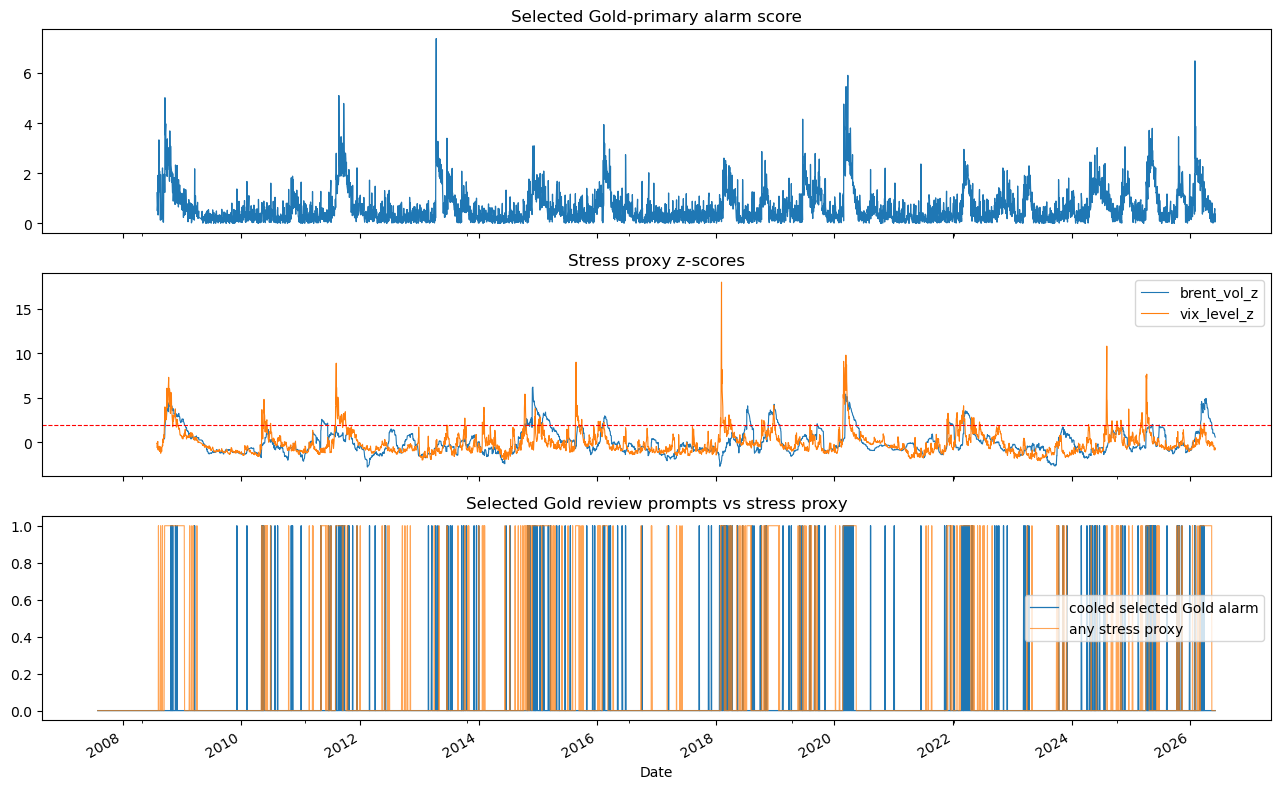

In [19]:
cooled_alarm = apply_cooldown(analysis["gold_alarm"], DEFAULT_COOLDOWN_DAYS)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
analysis["gold_primary_score"].plot(ax=axes[0], linewidth=0.9)
axes[0].set_title("Selected Gold-primary alarm score")

analysis[["brent_vol_z", "vix_level_z"]].plot(ax=axes[1], linewidth=0.8)
axes[1].axhline(2.0, color="red", linestyle="--", linewidth=0.8)
axes[1].set_title("Stress proxy z-scores")

cooled_alarm.plot(ax=axes[2], linewidth=0.9, label="cooled selected Gold alarm")
analysis["any_stress_proxy"].plot(ax=axes[2], linewidth=0.8, alpha=0.7, label="any stress proxy")
axes[2].legend()
axes[2].set_title("Selected Gold review prompts vs stress proxy")

plt.tight_layout()


## Step 07 Working Takeaways

This notebook evaluates the selected Gold alarm under an asymmetric cost framing: missing a stress event is far more costly than an unnecessary review.

**Primary result — named episode validation:**
The named event table is the honest answer to "did the signal work?" All 9 named stress episodes in the dataset were caught. The abstract coverage percentage against the stress proxy is supporting analysis — the named event table is the headline.

**Supporting results:**
- The selected alarm is the conditioned challenger, which achieves 68% stress proxy coverage at 10 reviews per year — materially better than the gold-primary score at identical firing frequency.
- At 95% coverage on the gold-primary score, Gold generates fewer false reviews than a random signal at the same frequency (35.1% vs 47.9%) — confirming Gold adds discriminatory value over random timing.
- The Brent return shock baseline achieves high coverage partly because Brent return shocks define the stress proxy. The random comparison is the more meaningful benchmark.
- Missed events cluster in regimes where Gold is structurally quiet — commodity-specific Brent return shocks not accompanied by safe-haven demand (41 of 56 missed events). This is a bounded, interpretable limitation.
- Brent vol and VIX-only signals cannot achieve 95% coverage of the stress proxy even at the lowest threshold — they are too sparse to serve as primary alarms.

In [20]:
default_summary.to_csv(OUTPUT_DIR / "default_operating_point_summary.csv", index=False)
default_acceptance.to_csv(OUTPUT_DIR / "default_operating_criteria_acceptance.csv", index=False)
default_event_table.to_csv(OUTPUT_DIR / "default_stress_event_coverage.csv", index=False)
default_alarm_table.to_csv(OUTPUT_DIR / "default_alarm_review_table.csv", index=False)
missed_stress_events.to_csv(OUTPUT_DIR / "missed_stress_events.csv", index=False)
false_review_prompts.to_csv(OUTPUT_DIR / "false_review_prompts.csv", index=False)
operating_grid.to_csv(OUTPUT_DIR / "cooldown_window_sensitivity_grid.csv", index=False)
operating_grid_acceptance.to_csv(OUTPUT_DIR / "operating_parameter_acceptance_grid.csv", index=False)
gold_primary_construction_sensitivity.to_csv(OUTPUT_DIR / "gold_primary_construction_parameter_sensitivity.csv", index=False)
coverage_by_family.to_csv(OUTPUT_DIR / "coverage_by_stress_family.csv", index=False)
alarm_design_comparison.to_csv(OUTPUT_DIR / "alarm_design_comparison.csv", index=False)
naive_baseline_comparison.to_csv(OUTPUT_DIR / "naive_baseline_comparison.csv", index=False)
random_baseline_results.to_csv(OUTPUT_DIR / "random_frequency_matched_baseline.csv", index=False)
random_summary.to_csv(OUTPUT_DIR / "random_frequency_matched_summary.csv")
sweep_df.to_csv(OUTPUT_DIR / "gold_primary_threshold_sweep.csv", index=False)
coverage_constrained_summary.to_csv(OUTPUT_DIR / "coverage_constrained_summary.csv", index=False)
missed_char_df.to_csv(OUTPUT_DIR / "missed_event_characterisation.csv", index=False)
missed_by_year.to_csv(OUTPUT_DIR / "missed_events_by_year.csv", index=False)
fixed_recall_comparison.to_csv(OUTPUT_DIR / "fixed_recall_baseline_comparison.csv", index=False)
named_event_validation.to_csv(OUTPUT_DIR / "named_event_validation.csv", index=False)

print("Saved Step 07 outputs to:", OUTPUT_DIR)

Saved Step 07 outputs to: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\outputs\step07_operational_usefulness
